# 2.2.2 从矩形累积到定积分

## 学习目标与先修知识

能把流率（flow rate）求和解释为定积分（definite integral）近似，用初值（initial condition）和净流率恢复存量（stock），并解释连续输入（input）与跳变输入下的累计曲线。

先修：上一节的极限（limit）与导数（derivative），有限求和和单位。 [复习上一节](01-从平均变化到导数.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

如果流入速率随时间增长为 u(t)=2t，0—1 T 一共流入多少？用起点流率算整段，会漏掉中途变大的流量（flow）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
rows=[]
for n in [1,2,4,8]:
    h=1/n
    rows.append((n,sum(2*(i*h)*h for i in range(n))))
display(Markdown(show_table(['等分段数','左端累计 / U'],rows)))

| 等分段数 | 左端累计 / U |
| --- | --- |
| 1 | 0 |
| 2 | 0.5 |
| 4 | 0.75 |
| 8 | 0.875 |

## 模型假设

流率是无噪声人工函数 $u(t)=2ct$，$c=1\;U/T^2$；0—1 T 内无清除、无内部生成。先计算累计流入，再加任意给定初始量。左端矩形在每个小区间冻结其左端速率，并不是把变化流率假设为真正恒定。

## 数学解释与推导

用 n 个宽度为 $h=(b-a)/n$ 的矩形相加：
$$L_n=\sum_{i=0}^{n-1}u(a+ih)h.$$
流率 U/T 乘 h 的 T 后，每项都是 U。若函数连续，细分趋向无限时矩形总量趋于定积分，记为 $\int_a^b u(t)\,dt$。符号 dt 提示累积的是“沿时间的微小变化”，积分上下限决定区间。

本例在 [0,1] 上有 $L_n=\frac{2}{n^2}\sum_{i=0}^{n-1}i$。首尾配对给出 $\sum i=n(n-1)/2$，因此 $L_n=1-1/n$，精确面积为 1 U。左端法低估，因为流率递增；若流率递减，偏差方向会反转。

令 $B(t)=\int_0^t u(s)ds$。短区间的新增量约为 $u(t)\Delta t$，除以 $\Delta t$ 并取极限，在 u 连续处得到 $B'(t)=u(t)$，这就是微积分基本定理（fundamental theorem of calculus）的一面。反过来，若 $F'=u$，则积分为 $F(b)-F(a)$；因为 B 和 F 有相同导数，只差一个常数。

这里 $F(t)=t^2$，所以 $\int_a^b2t\,dt=b^2-a^2$。若同时有流出 v(t)，则
$$A(t)=A(0)+\int_0^t[u(s)-v(s)]ds.$$
有有限流率跳变时累计量仍连续，但斜率（slope）可以左右不同；瞬时注入需要另立跳跃模型（model），不能混入当前假设。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def left_area(start, end, intervals):
    h = (end - start) / intervals
    total = 0.0
    for i in range(intervals):
        time = start + i * h
        total += (2 * time) * h
    return total

## 对照实验

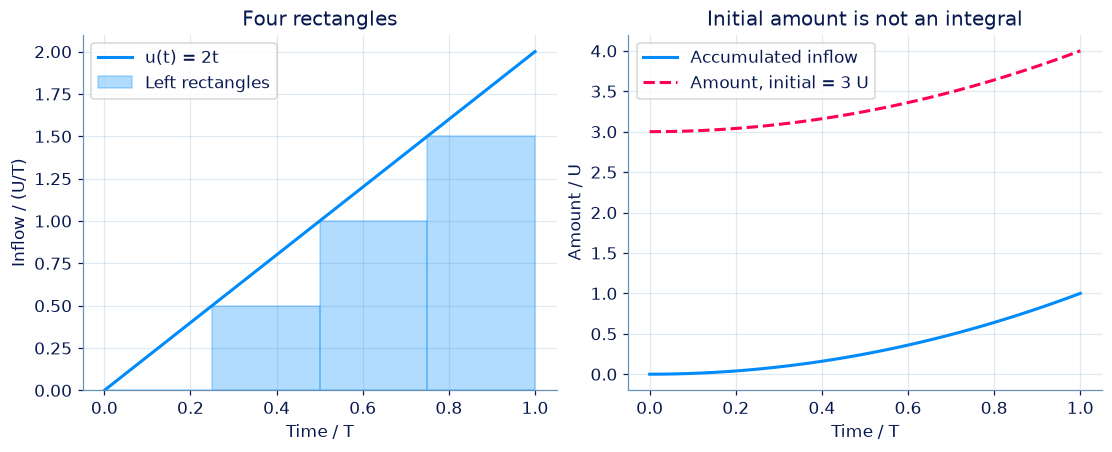

| n | 左端累计 / U | 与 1 U 的差 |
| --- | --- | --- |
| 4 | 0.75 | 0.25 |
| 8 | 0.875 | 0.125 |
| 16 | 0.9375 | 0.0625 |
| 32 | 0.96875 | 0.03125 |

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
n=4;h=1/n;left=np.arange(n)*h
axes[0].bar(left,2*left,width=h,align='edge',alpha=.3,edgecolor='#008bfb',label='Left rectangles')
t=np.linspace(0,1,101);axes[0].plot(t,2*t,label='u(t) = 2t')
axes[0].set(xlabel='Time / T',ylabel='Inflow / (U/T)',title='Four rectangles');axes[0].legend()
axes[1].plot(t,t**2,label='Accumulated inflow')
axes[1].plot(t,3+t**2,'--',label='Amount, initial = 3 U')
axes[1].set(xlabel='Time / T',ylabel='Amount / U',title='Initial amount is not an integral');axes[1].legend()
plt.show()
display(Markdown(show_table(['n','左端累计 / U','与 1 U 的差'],[(n,left_area(0,1,n),1-left_area(0,1,n)) for n in [4,8,16,32]])))

## 结果解释

四个矩形合计 0.75 U，不是精确积分 1 U。细分后漏掉的面积减少。右图两条曲线导数相同，却始终相差 3 U；这说明变化率与初值承担不同信息。

### 独立核对

这里用三角形面积核对矩形求和；随着分段变细，比较两者的差怎样缩小。

In [5]:
for n in [1,4,10,100]:
    assert math.isclose(left_area(0,1,n),1-1/n,abs_tol=1e-12)
    # For u=2t, each left rectangle misses exactly h squared.
    a,b=1,3;h=(b-a)/n
    assert math.isclose(left_area(a,b,n),b*b-a*a-n*h*h,abs_tol=1e-11)
print('矩形求和与有限和闭式一致；单位和初值分别保留。')

矩形求和与有限和闭式一致；单位和初值分别保留。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：流率曲线下面的面积

某物质只有流入，u(t) 的单位为 U/T，初始所追踪物质总量（tracked amount）为 3 U。0—2 T 内 u(t) 的定积分（definite integral）为 4 U。哪些结论正确？

- **A.** 流入累计量为 4 U。
- **B.** 终点总量为 4 U。
- **C.** 终点总量为 7 U。
- **D.** 定积分的单位为 U/T²。

[作答：流率曲线下面的面积](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-area-unit)

### 第 2 题 · Python 计算题：用左端矩形累积变化

流入速率 u(t)=2t，t 以 T 为单位。把 [start,end] 等分成 intervals 段，用每段左端速率乘段宽，返回累计近似。

**函数与代码模板**

```python
def solve(
    start: float,
    end: float,
    intervals: int,
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `start` | `float` | 起始时刻。 | T |
| `end` | `float` | 终止时刻。 | T |
| `intervals` | `int` | 等分段数。 | 段 |

**返回值**

直接返回 total（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total` | `float` | 左端矩形累计量。 | U |

**计算规则**

h=(end−start)/intervals；累加 2×(start+i×h)×h，i 从 0 到 intervals−1。题目要求近似和，不能直接返回精确积分 end²−start²。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 0 ≤ start < end ≤ 10；1 ≤ intervals ≤ 10000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| start | 起始时刻。 | 0 | T |
| end | 终止时刻。 | 1 | T |
| intervals | 等分段数。 | 4 | 段 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
start = 0
end = 1
intervals = 4

result = solve(start, end, intervals)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| total | 左端矩形累计量。 | 0.75 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.75
```

**样例解释**

四段左端为 0、0.25、0.5、0.75 T；流率（flow rate）为 0、0.5、1、1.5 U/T，乘 0.25 T 后合计 0.75 U。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：用左端矩形累积变化](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-left-area)

### 第 3 题 · 单项选择题：累积函数的变化率

令 B(t)=∫₀ᵗ u(s) ds，且 u 在考察时刻连续。哪一项是微积分基本定理（fundamental theorem of calculus）在这里的含义？

- **A.** B(t)=u(t)。
- **B.** B′(t)=u(t)。
- **C.** B′(t)=0。
- **D.** 只要知道 B′，无需初值（initial condition）就能确定原存量（stock）。

[作答：累积函数的变化率](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-ftc)

### 第 4 题 · 多项选择题：输入跳变时存量是否跳变

只有有限流率（flow rate）输入（input）：0—1 T 为 2 U/T，1—2 T 为 0；没有瞬时注入、没有清除。哪些说法正确？

- **A.** t=1 T 时累计量连续。
- **B.** t=1 T 时累计曲线的左右斜率（slope）不同。
- **C.** 流率从 2 变 0，存量（stock）必须瞬间减少 2 U。
- **D.** 对该输入直接用一条处处光滑曲线会掩盖跳变。

[作答：输入跳变时存量是否跳变](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-jump-area)

**进一步阅读**

[MIT 定积分与基本定理](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/pages/unit-3-the-definite-integral-and-its-applications/part-a-definition-of-the-definite-integral-and-first-fundamental-theorem/)：定义与变化/累积的联系。